# <center> **Phase III: Model Training**

In [1]:
import os
os.getcwd()
os.chdir('E:/DSP')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PowerTransformer, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df_train = pd.read_csv('study_materials/LearnML/regression_project/house-prices-advanced-regression-techniques/train.csv')
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df_train = df_train.drop(index=[249, 313, 335, 706, 523, 1182, 1298])

In [6]:
y = np.log1p(df_train['SalePrice'])
X = df_train.drop(columns=['Id', 'SalePrice'], errors='ignore')

In [7]:
X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [8]:
y.head()

0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice, dtype: float64

In [9]:
def custom_imputer(df_input):
    # Replacing null values
    df_out = df_input.copy()
    cat_replacements = {
        'Alley': 'No alley access', 
        'MasVnrType': 'None', 
        'BsmtQual': 'No basement',
        'BsmtCond': 'No basement', 
        'BsmtExposure': 'No basement', 
        'BsmtFinType1': 'No basement',
        'BsmtFinType2': 'No basement', 
        'GarageType': 'No garage', 
        'GarageFinish': 'No garage',
        'GarageQual': 'No garage', 
        'GarageCond': 'No garage', 
        'Fence': 'No fence', 
        'MiscFeature': 'No extras'
    }
    df_out.fillna(value=cat_replacements, inplace=True)
    
    if 'GarageYrBlt' in df_out.columns:
        df_out['GarageYrBlt'] = df_out['GarageYrBlt'].fillna(0)

    if 'FireplaceQu' in df_out.columns and 'Fireplaces' in df_out.columns:
        df_out.loc[(df_out['FireplaceQu'].isnull()) & (df_out['Fireplaces'] == 0), 'FireplaceQu'] = 'No fireplace'
        df_out['FireplaceQu'] = df_out['FireplaceQu'].fillna('No fireplace')
        
    if 'PoolQC' in df_out.columns and 'PoolArea' in df_out.columns:
        df_out.loc[(df_out['PoolQC'].isnull()) & (df_out['PoolArea'] == 0), 'PoolQC'] = 'No pool'
        df_out['PoolQC'] = df_out['PoolQC'].fillna('No pool')

    nan_columns = df_out.columns[df_out.isnull().any()].tolist()
    train_medians = X.median(numeric_only=True)
    train_modes = X.select_dtypes(include=['object', 'category']).mode().iloc[0]
    for col in nan_columns:
        if df_out[col].dtype == 'object' or df_out[col].dtype.name == 'category':
            # Use the locked training mode for this column
            fallback_mode = train_modes[col] if col in train_modes else 'missing'
            df_out[col] = df_out[col].fillna(fallback_mode)
        else:
            # Use the locked training median for this column
            fallback_median = train_medians[col] if col in train_medians else 0
            df_out[col] = df_out[col].fillna(fallback_median)
            
    return df_out

In [10]:
# Split features according to the way of encoding
ohe_cols = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
            'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'HouseRemod', 'RoofStyle',
            'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'LowQualFin',
            'Heating', 'CentralAir', 'Electrical', 'GarageType', 'PavedDrive', 'Pool', 'MiscVal?',
            'MiscFeature', 'SaleType', 'MoSold', 'SaleCondition']

orde_cols = ['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
             'Functional','BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'PoolQC', 
             'GarageFinish', 'GarageQual', 'GarageCond', 'Fence']

# Explicit Ordinal Maps
exter_qual_cond_categories = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
bsmt_qual_cond_categories = ['No basement', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
bsmt_expo_categories = ['No basement', 'No', 'Mn', 'Av', 'Gd']
functional_categories = ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']
bsmt_fin_categories = ['No basement', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
heat_kitchen_categories = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
fireplace_categories = ['No fireplace', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
pool_categories = ['No pool', 'Fa', 'TA', 'Gd', 'Ex']
garage_finish_categories = ['No garage', 'Unf', 'RFn', 'Fin']
garage_qual_cond_categories = ['No garage', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
fence_categories = ['No fence', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']

ordinal_categories_order = [
    list(range(1, 11)),                # OverallQual (1 to 10)
    list(range(1, 11)),                # OverallCond (1 to 10)
    exter_qual_cond_categories,        # ExterQual
    exter_qual_cond_categories,        # ExterCond
    bsmt_qual_cond_categories,         # BsmtQual
    bsmt_qual_cond_categories,         # BsmtCond
    bsmt_expo_categories,              # BsmtExposure
    functional_categories,             # Functional
    bsmt_fin_categories,               # BsmtFinType1
    bsmt_fin_categories,               # BsmtFinType2
    heat_kitchen_categories,           # HeatingQC
    heat_kitchen_categories,           # KitchenQual
    fireplace_categories,              # FireplaceQu
    pool_categories,                   # PoolQC
    garage_finish_categories,          # GarageFinish
    garage_qual_cond_categories,       # GarageQual
    garage_qual_cond_categories,       # GarageCond
    fence_categories                   # Fence 
]

# Store variables that needs to be transformed accordingly
yeo_cols = ['LotFrontage', 'BsmtUnfSF', 'TotalBsmtSF', 'TotalPorchSF', 'GarageArea']
log_cols = ['LotArea', 'MasVnrArea', 'BsmtFinSF1', '1stFlrSF', '2ndFlrSF', 'GrLivArea']

# Store variables that needs to be scaled
scal_cols = ['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
             'BsmtFinType1', 'BsmtFinType2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
             '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'TotRmsAbvGrd', 'OthRmsAbvGrd',
             'GarageYrBlt', 'GarageArea', 'OpenPorchSF', 'WoodDeckSF', 'EnclosedPorch',
             '3SSnPorch', 'ScreenPorch', 'TotalPorchSF', 'PoolArea', 'MiscVal', 'HouseAge',
             'YrSold']

In [11]:
def create_new_features(df_input):
    df_out = df_input.copy()
    
    # House age
    df_out['HouseAge'] = df_out['YrSold'] - df_out['YearBuilt']
    
    # Other rooms above grade
    df_out['OthRmsAbvGrd'] = df_out['TotRmsAbvGrd'] - (df_out['BedroomAbvGr'] + df_out['KitchenAbvGr'])

    # House remodeled or not
    df_out['HouseRemod'] = df_out.apply(lambda x: 'Y' if x['YearRemodAdd'] > x['YearBuilt'] else 'N', axis=1)

    # Total Porch Sqft
    df_out['TotalPorchSF'] = df_out['WoodDeckSF'] + df_out['OpenPorchSF'] + df_out['EnclosedPorch'] + df_out['3SsnPorch'] + df_out['ScreenPorch']

    # Low Quality Fin
    df_out['LowQualFin'] = df_out.apply(lambda x: 'Y' if x['LowQualFinSF'] > 0 else 'N', axis=1)
    
    # Pool existence
    df_out['Pool'] = df_out.apply(lambda x: 'Y' if x['PoolArea'] > 0 else 'N', axis=1)

    # Miscellaneous expense existence
    df_out['MiscVal?'] = df_out.apply(lambda x: 'Y' if x['MiscVal'] > 0 else 'N', axis=1)
    return df_out

In [12]:
# Numerical column: imputation, transformation and scaling
# Numerical Sub-Pipeline 1: For columns requiring Yeo-Johnson transformation
num_yj_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('yj', PowerTransformer(method='yeo-johnson', standardize=False)),
    ('scaler', StandardScaler())
])
# Numerical Sub-Pipeline 2: For columns requiring Log1p transformation
num_log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

In [13]:
# Final preprocessor column transformer
preprocessor = ColumnTransformer(
    transformers=[
        # Categorical transformations
        ('nominal', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ohe_cols),
        ('ordinal', OrdinalEncoder(categories=ordinal_categories_order, handle_unknown='use_encoded_value', unknown_value=-1), orde_cols),
        # Numerical transformations
        ('num_yj', num_yj_pipeline, yeo_cols),
        ('num_log', num_log_pipeline, log_cols)
    ],
    remainder='passthrough'
)

# Final pipeline (under construction)
processing_pipeline = Pipeline([
    ('custom_impute', FunctionTransformer(custom_imputer, validate=False)),
    ('feature_engineering', FunctionTransformer(create_new_features, validate=False)),
    ('preprocessor', preprocessor)
])

In [14]:
preprocessor

,transformers,"[('nominal', ...), ('ordinal', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,False


In [15]:
processing_pipeline

,steps,"[('custom_impute', ...), ('feature_engineering', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cus...002735F3BD800>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


**Comparison of Models**

Tier 1:
- Linear Regression
- Lasso Regression
- Ridge Regression

Tier 2:
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor
- LightGBM Regressor

In [16]:
# 5-fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [17]:
# create model instance
linear_model = LinearRegression()
lasso_model = LassoCV(alphas=np.logspace(-4, 1, 100), cv=kf, max_iter=10000, random_state=42)
ridge_model = RidgeCV(alphas=np.logspace(-3, 2, 100), cv=kf)
dt_model = DecisionTreeRegressor(max_depth=4, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.07, random_state=42, n_jobs=-1)
lgb_model = LGBMRegressor(n_estimators=100, learning_rate=0.07, random_state=42, n_jobs=-1, verbose=-1)


models = {'Linear': linear_model, 'Lasso': lasso_model, 'Ridge': ridge_model, 
          'Decision Tree': dt_model, 'Random Forest': rf_model, 'XGBoost': xgb_model, 'LightGBM': lgb_model}

In [18]:
perf = pd.DataFrame(columns=['model', 'train_mse', 'test_mse',
                                      'train_mae', 'test_mae', 
                                      'train_r2', 'test_r2'])
for name, model in models.items():                                                          # store model scores
    val_mse_scores, train_mse_scores = [], []
    val_r2_scores, train_r2_scores = [], []
    val_mae_scores, train_mae_scores = [], []
    
    for train_idx, val_idx in kf.split(X):
        
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        X_train_processed = processing_pipeline.fit_transform(X_train_fold, y_train_fold)  # encoding and transforming
        X_val_processed = processing_pipeline.transform(X_val_fold)                      

        model.fit(X_train_processed, y_train_fold)                                         # fit model to processed train fold
        val_predictions = model.predict(X_val_processed)                                  # predict validation folds using the model
        train_predictions = model.predict(X_train_processed)                               # predict train folds using the model
        
        val_mse = mean_squared_error(y_val_fold, val_predictions)                        # evaluate metrics
        val_r2 = r2_score(y_val_fold, val_predictions)
        val_mae = mean_absolute_error(y_val_fold, val_predictions)

        val_mse_scores.append(val_mse)
        val_r2_scores.append(val_r2)
        val_mae_scores.append(val_mae)
        
        train_mse = mean_squared_error(y_train_fold, train_predictions)                    # evaluate metrics
        train_r2 = r2_score(y_train_fold, train_predictions)
        train_mae = mean_absolute_error(y_train_fold, train_predictions)

        train_mse_scores.append(train_mse)
        train_r2_scores.append(train_r2)
        train_mae_scores.append(train_mae)

    mean_val_mse = sum(val_mse_scores)/len(val_mse_scores)
    mean_val_mae = sum(val_mae_scores)/len(val_mae_scores)
    mean_val_r2=sum(val_r2_scores)/len(val_r2_scores)

    mean_train_mse = sum(train_mse_scores)/len(train_mse_scores)
    mean_train_mae = sum(train_mae_scores)/len(train_mae_scores)
    mean_train_r2=sum(train_r2_scores)/len(train_r2_scores)

    mean_perf = pd.DataFrame(data=[[name, mean_train_mse, mean_val_mse,
                                    mean_train_mae, mean_val_mae,
                                    mean_train_r2, mean_val_r2]], 
                             columns=['model', 'train_mse', 'test_mse',
                                               'train_mae', 'test_mae', 
                                               'train_r2', 'test_r2'])

    perf = pd.concat([perf, mean_perf], axis=0)
    
perf.reset_index(drop=True,inplace=True)
perf

,model,train_mse,test_mse,train_mae,test_mae,train_r2,test_r2
0,Linear,0.007854,0.015172,0.063091,0.083864,0.950164,0.902703
1,Lasso,0.009811,0.012668,0.070530,0.078108,0.937744,0.919071
2,Ridge,0.009647,0.012641,0.069490,0.078069,0.938804,0.919315
3,Decision Tree,0.032388,0.042505,0.135640,0.154377,0.794583,0.729309
4,Random Forest,0.002745,0.018956,0.035513,0.094621,0.982586,0.879085
5,XGBoost,0.001051,0.017184,0.024137,0.090793,0.993329,0.890453
6,LightGBM,0.002481,0.015595,0.032539,0.085783,0.984261,0.900682


Classic regression models outperformed the tree regressors. The next step is to tune the model. Since linear regression model has no hyperparameters, the other two regularized models are considered. But then again, since LassoCV and RidgeCV are used, the model identifies an optimal alpha value that yields less error automatically. Further step is to fit the model on the training set and obtain that optimal alpha value.

In [19]:
# Fit the ridge model with optimum alpha value to the entire dataset
ridge_pipeline = Pipeline([('processing', processing_pipeline), ('ridge', ridge_model)])
ridge_pipeline.fit(X, y)

# Get the optimum alpha value
print(f"Optimal Ridge Alpha Value: {ridge_pipeline.named_steps['ridge'].alpha_:.4f}")

# Get the coefficients of the features
feature_names = ridge_pipeline.named_steps['processing'].named_steps['preprocessor'].get_feature_names_out()
ridge_coefs = ridge_pipeline.named_steps['ridge'].coef_
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': ridge_coefs})

print("\nTop 10 Most Influential Features in Ridge Model:")
coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()
print(coef_df.sort_values(by='Absolute_Coefficient', ascending=False).head(10))

Optimal Ridge Alpha Value: 13.8489

Top 10 Most Influential Features in Ridge Model:
                           Feature  Coefficient  Absolute_Coefficient
210             num_log__GrLivArea     0.092277              0.092277
39   nominal__Neighborhood_Crawfor     0.081916              0.081916
55   nominal__Neighborhood_StoneBr     0.062912              0.062912
180  nominal__SaleCondition_Normal     0.060139              0.060139
42    nominal__Neighborhood_IDOTRR    -0.058810              0.058810
202            num_yj__TotalBsmtSF     0.053799              0.053799
14            nominal__MSZoning_FV     0.053518              0.053518
59        nominal__Condition1_Norm     0.051734              0.051734
163          nominal__SaleType_New     0.051250              0.051250
182           ordinal__OverallQual     0.051127              0.051127


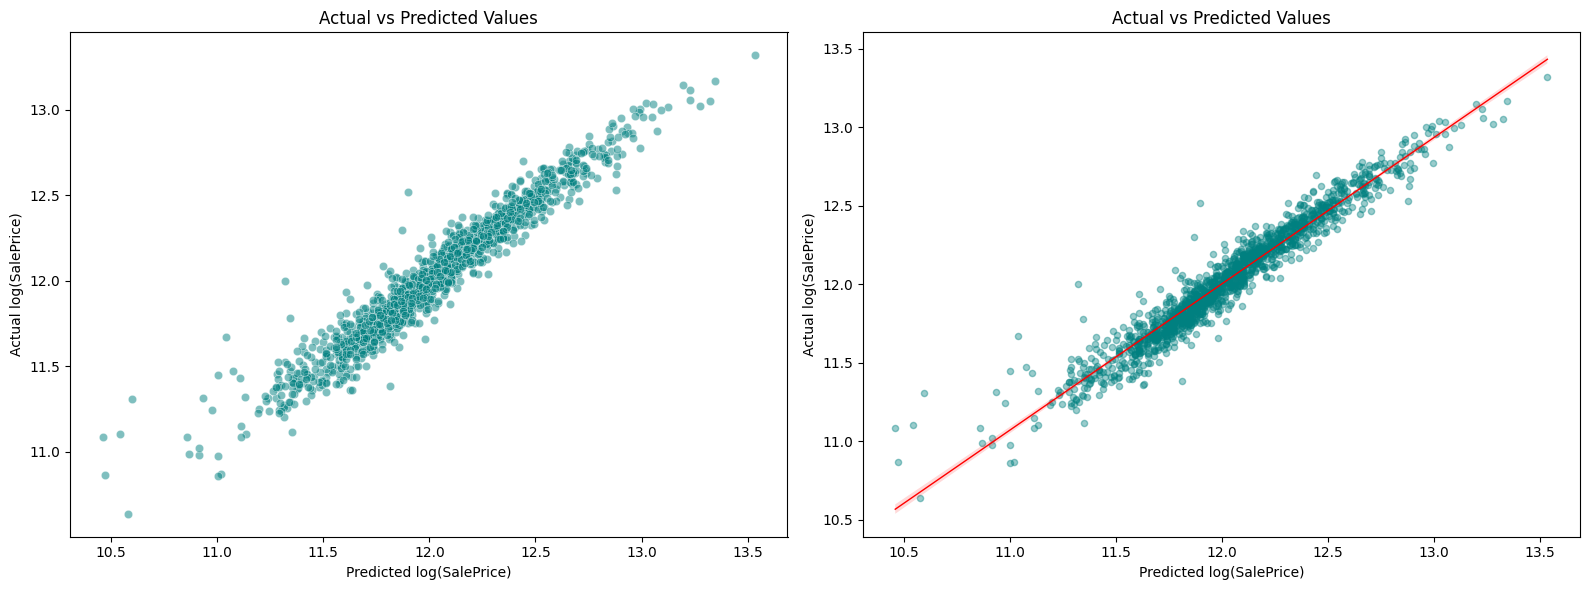

In [20]:
# Regression plot
y_pred = ridge_pipeline.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=y, y=y_pred, alpha=0.5, ax=axes[0], color='teal')
axes[0].set_title('Actual vs Predicted Values')
axes[0].set_xlabel('Predicted log(SalePrice)')
axes[0].set_ylabel('Actual log(SalePrice)')

sns.regplot(x=y, y=y_pred, ax=axes[1], 
            scatter_kws={'alpha': 0.4, 's':20, 'color': 'teal'}, 
            line_kws = {'color': 'red', 'lw':1})
axes[1].set_title('Actual vs Predicted Values')
axes[1].set_xlabel('Predicted log(SalePrice)')
axes[1].set_ylabel('Actual log(SalePrice)')

plt.tight_layout()
plt.show()

# <center> **Phase IV: Complete Model Pipeline Construction**

In [25]:
from sklearn.linear_model import Ridge

In [29]:
import sys
import os
sys.path.append('study_materials/LearnML/regression_project/module/')

from imputation_feature_create import ProductionImputer, ProductionFeatureEngineer

In [30]:
# Build the complete model pipeline
final_pipeline = Pipeline([
    ('production_impute', ProductionImputer()),          
    ('feature_engineering', ProductionFeatureEngineer()), 
    ('preprocessor', preprocessor),                       
    ('ridge_model', Ridge(alpha=13.8489))                 
])

# Fit on training data
trained_pipeline = final_pipeline.fit(X, y)

In [31]:
import joblib
joblib.dump(trained_pipeline, 'study_materials/LearnML/regression_project/model/house_price_ridge_pipeline.pkl')

['study_materials/LearnML/regression_project/model/house_price_ridge_pipeline.pkl']